In [116]:
# ==========================================================
# IMPORTS
# ==========================================================
import pandas as pd
import numpy as np
import datetime as datetime
from datetime import timedelta
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# ==========================================================
# LOAD DATA
# ==========================================================
donors = pd.read_csv(r".\Data\donors.csv", sep=',')
gifts = pd.read_csv(r".\Data\gifts.csv")
campaign_6169 = pd.read_csv(r".\Data\selection campaign 6169.csv")
campaign_7244 = pd.read_csv(r".\Data\selection campaign 7244.csv")

# ==========================================================
# CLEAN DONORS DATA
# ==========================================================
donors["dateOfBirth"] = pd.to_datetime(donors["dateOfBirth"], format="%m/%d/%Y")
donors.loc[donors["province"] == "ANTWERP", "province"] = "Antwerp"

donors["zipcode"] = donors["zipcode"].astype("Int64").astype(str)
donors["zipcode"] = donors["zipcode"].fillna("Unknown")

# ==========================================================
# CLEAN GIFTS
# ==========================================================
def clean_amount(amount_str):
    if pd.isna(amount_str):
        return None
    amount_str = amount_str.replace('.', '')
    amount_str = amount_str.replace(',', '.')
    parts = amount_str.split('.')
    if len(parts) > 1:
        cleaned = parts[0] + '.' + parts[1][:3]
    else:
        cleaned = parts[0]
    try:
        return np.round(float(cleaned), 2)
    except:
        return None

gifts['amount_cleaned'] = gifts['amount'].apply(clean_amount)
gifts = gifts.drop(columns=['amount'])
gifts['date'] = pd.to_datetime(gifts['date'], format="%d/%m/%Y")
gifts['campaignID'] = gifts['campaignID'].astype('Int64')

# ==========================================================
# FEATURE ENGINEERING FUNCTION
# ==========================================================
def build_features(donors, gifts, campaign, drop_date,campaignID,
                   lookback_days=1900, target_days=250, median_age=None):

    D = pd.to_datetime(drop_date, format="%d/%m/%Y")
    df = campaign.merge(donors, on='donorID', how='left')

    # AGE
    df["age"] = D.year - df["dateOfBirth"].dt.year
    df["age_missing"] = df["age"].isna().astype(int)
    if median_age is None:
        df["age"] = df["age"].fillna(df["age"].median())
    else:
        df["age"] = df["age"].fillna(median_age)

    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 17, 35, 64, float("inf")],
        labels=["Child", "Young Adult", "Adult", "Senior"]
    ).astype("object")

    # ======================================================
    # TRAINING-SET GIFT HISTORY
    # ======================================================
    start = D - timedelta(days=lookback_days)
    gifts_train = gifts[(gifts["date"] >= start) & (gifts["date"] < D)]

    training = gifts_train.groupby("donorID").agg(
        last_gift=("date", "max"),
        first_gift=("date", "min"),
        n_gifts=("amount_cleaned", "count"),
        total_amount=("amount_cleaned", "sum"),
        avg_amount=("amount_cleaned", "mean"),
        max_amount=("amount_cleaned", "max")
    ).reset_index()

    training["recency_days"] = (D - training["last_gift"]).dt.days
    training["lifetime_days"] = (D - training["first_gift"]).dt.days

    # Extra strong features
    training["gift_interval"] = training["lifetime_days"] / (training["n_gifts"] + 1)
    training["avg_to_max_ratio"] = training["avg_amount"] / (training["max_amount"] + 1)

    df = df.merge(training, on="donorID", how="left")

    # ======================================================
    # TARGET (future gifts)
    # ======================================================
    end = D + timedelta(days=target_days)
    gifts_future = gifts[(gifts["date"] > D) & (gifts["date"] <= end)& (gifts['campaignID']==campaignID)]

    fut = (
        gifts_future.groupby("donorID")["amount_cleaned"]
        .sum()
        .reset_index()
        .rename(columns={"amount_cleaned": "future_amount"})
    )

    # requirement: must donate at least 30 EUR
    fut = fut[fut["future_amount"] >= 30]

    df["target"] = df["donorID"].isin(fut["donorID"]).astype(int)

    # MISSING DATA HANDLING
    df["recency_missing"] = df["recency_days"].isna().astype(int)
    df["recency_days"] = df["recency_days"].fillna(9999)

    df = df.drop(columns=["zipcode", "last_gift", "first_gift", "dateOfBirth"], errors="ignore")

    # Fill missing numeric
    for col in df.select_dtypes(include=["number"]).columns:
        df[col] = df[col].fillna(0)

    # Fill missing categorical
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].fillna("missing")

    df = pd.get_dummies(
        df,
        columns=["gender", "province", "region", "language", "age_group"],
        dtype=int
    )

    return df

# ==========================================================
# BUILD TRAIN + TEST SETS
# ==========================================================
train = build_features(donors, gifts, campaign_6169,campaignID=6169,
                       drop_date="04/09/2018")

train_median_age = train["age"].median()

test = build_features(donors, gifts, campaign_7244,campaignID=7244,
                      drop_date="18/06/2019",
                      median_age=train_median_age)

# Align columns
train, test = train.align(test, join="outer", axis=1, fill_value=0)

# ==========================================================
# TRAIN / TEST SPLITS
# ==========================================================
X_train = train.drop(columns=["donorID", "target"])
y_train = train["target"]

X_test = test.drop(columns=["donorID", "target"])
y_test = test["target"]

# ==========================================================
# SCALING
# ==========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)








In [77]:
# ==========================================================
# MODEL — GRADIENT BOOSTING (strong for lift)
# ==========================================================
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    n_estimators=1000,        # Increase number of trees
    learning_rate=0.03,       # Lower learning rate for smoother learning
    max_depth=4,              # Shallower trees often generalize better
    min_child_weight=1,       # Prevent overfitting on small leaves
    subsample=0.8,            # Random sample of rows per tree
    colsample_bytree=0.8,     # Random sample of features per tree
    gamma=0.1,                # Minimum loss reduction to make a split
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)


In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # SMOTE ONLY on training fold
    sm = SMOTE(random_state=42)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)

    # Train model
    xgb_model.fit(X_tr_bal, y_tr_bal)

    # Get probabilities
    y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

    # AUC
    aucs.append(roc_auc_score(y_val, y_val_proba))

print("CV AUC:", np.mean(aucs))


c:\Users\Source\.conda\envs\py\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Source\.conda\envs\py\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Source\.conda\envs\py\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Source\.conda\envs\py\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not

CV AUC: 0.8023011329453033


In [79]:
# Rebalance full training data
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

# Train final XGBoost model
xgb_model.fit(X_train_bal, y_train_bal)

# Predict probabilities on TEST set
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]


c:\Users\Source\.conda\envs\py\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [80]:
y_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

test["proba"] = y_test_proba
test["target"] = y_test.values

In [81]:
test["decile"] = pd.qcut(test["proba"], 10, labels=False, duplicates="drop")

lift = (
    test.groupby("decile")
        .agg(
            n=("target", "count"),
            responders=("target", "sum"),
            avg_proba=("proba", "mean")
        )
        .sort_index(ascending=False)
)

lift["response_rate"] = lift["responders"] / lift["n"]
lift["lift"] = lift["response_rate"] / test["target"].mean()

print(lift)

           n  responders  avg_proba  response_rate      lift
decile                                                      
9       2543          67   0.985358       0.026347  3.113662
8       2575          29   0.967135       0.011262  1.330956
7       2574          40   0.940415       0.015540  1.836515
6       2539          24   0.893312       0.009453  1.117099
5       2574          14   0.834970       0.005439  0.642780
4       2578          16   0.706315       0.006206  0.733466
3       2568          13   0.443974       0.005062  0.598262
2       2565          12   0.166027       0.004678  0.552888
1       2564           1   0.047814       0.000390  0.046092
0       2565           1   0.008555       0.000390  0.046074


In [82]:
test_sorted = test.sort_values("proba", ascending=False)
test_sorted["cum_responders"] = test_sorted["target"].cumsum()
test_sorted["cum_perc_responders"] = test_sorted["cum_responders"] / test_sorted["target"].sum()
test_sorted["cum_perc_population"] = np.arange(1, len(test_sorted)+1) / len(test_sorted)


In [83]:
gain = test_sorted[["cum_perc_population","cum_perc_responders"]]


In [84]:
import numpy as np
import pandas as pd

# Sort probabilities descending
df_cut = pd.DataFrame({
    "proba": y_test_proba  # <-- use your test set probabilities
}).sort_values("proba", ascending=False).reset_index(drop=True)

# Percentiles for top segments
cutoffs = {
    "Top 5%": df_cut["proba"].quantile(0.95),
    "Top 10%": df_cut["proba"].quantile(0.90),
    "Top 20%": df_cut["proba"].quantile(0.80),
    "Top 30%": df_cut["proba"].quantile(0.70),
    "Top 50%": df_cut["proba"].quantile(0.50)
}

cutoffs


{'Top 5%': np.float64(0.9854025363922119),
 'Top 10%': np.float64(0.9750210046768188),
 'Top 20%': np.float64(0.9583936929702759),
 'Top 30%': np.float64(0.921773374080658),
 'Top 50%': np.float64(0.7966051697731018)}

In [85]:
thresholds = {
    "Top 5%": 0.9854025363922119,
    "Top 10%": 0.9750210046768188,
    "Top 20%": 0.9583936929702759,
    "Top 30%": 0.921773374080658,
    "Top 50%": 0.7966051697731018
}

for name, thr in thresholds.items():
    count = (y_test_proba >= thr).sum()
    responders = y_test[(y_test_proba >= thr)].sum()
    print(f"{name}: {count} donors, {responders} expected responders")


Top 5%: 1283 donors, 44 expected responders
Top 10%: 2583 donors, 67 expected responders
Top 20%: 5154 donors, 97 expected responders
Top 30%: 7700 donors, 136 expected responders
Top 50%: 12858 donors, 174 expected responders


In [86]:
import pandas as pd
import numpy as np

# Create DataFrame for evaluation
df_profit = pd.DataFrame({
    "y_true": y_test,
    "proba": y_test_proba
})

# Sort donors by predicted probability (high → low)
df_profit = df_profit.sort_values("proba", ascending=False).reset_index(drop=True)

# Campaign assumptions
mail_cost = 0.80
avg_donation = 50

# Segments we evaluate
segments = {
    "Top 5%": 0.05,
    "Top 10%": 0.10,
    "Top 20%": 0.20,
    "Top 30%": 0.30,
    "Top 50%": 0.50
}

results = []

N = len(df_profit)

for name, frac in segments.items():
    cutoff = int(N * frac)

    df_seg = df_profit.iloc[:cutoff]

    mailed = len(df_seg)
    responders = df_seg["y_true"].sum()

    revenue = responders * avg_donation
    cost = mailed * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost > 0 else 0

    results.append([name, mailed, responders, revenue, cost, profit, roi])

# Convert to table
profit_table = pd.DataFrame(results, columns=[
    "Segment", "Donors Mailed", "Responders", "Revenue (€)", "Cost (€)", "Profit (€)", "ROI"
])

profit_table


,Segment,Donors Mailed,Responders,Revenue (€),Cost (€),Profit (€),ROI
0,Top 5%,1282,44,2200,1025.6,1174.4,2.145086
1,Top 10%,2564,67,3350,2051.2,1298.8,1.633190
2,Top 20%,5129,96,4800,4103.2,696.8,1.169819
3,Top 30%,7693,136,6800,6154.4,645.6,1.104901
4,Top 50%,12822,174,8700,10257.6,-1557.6,0.848152


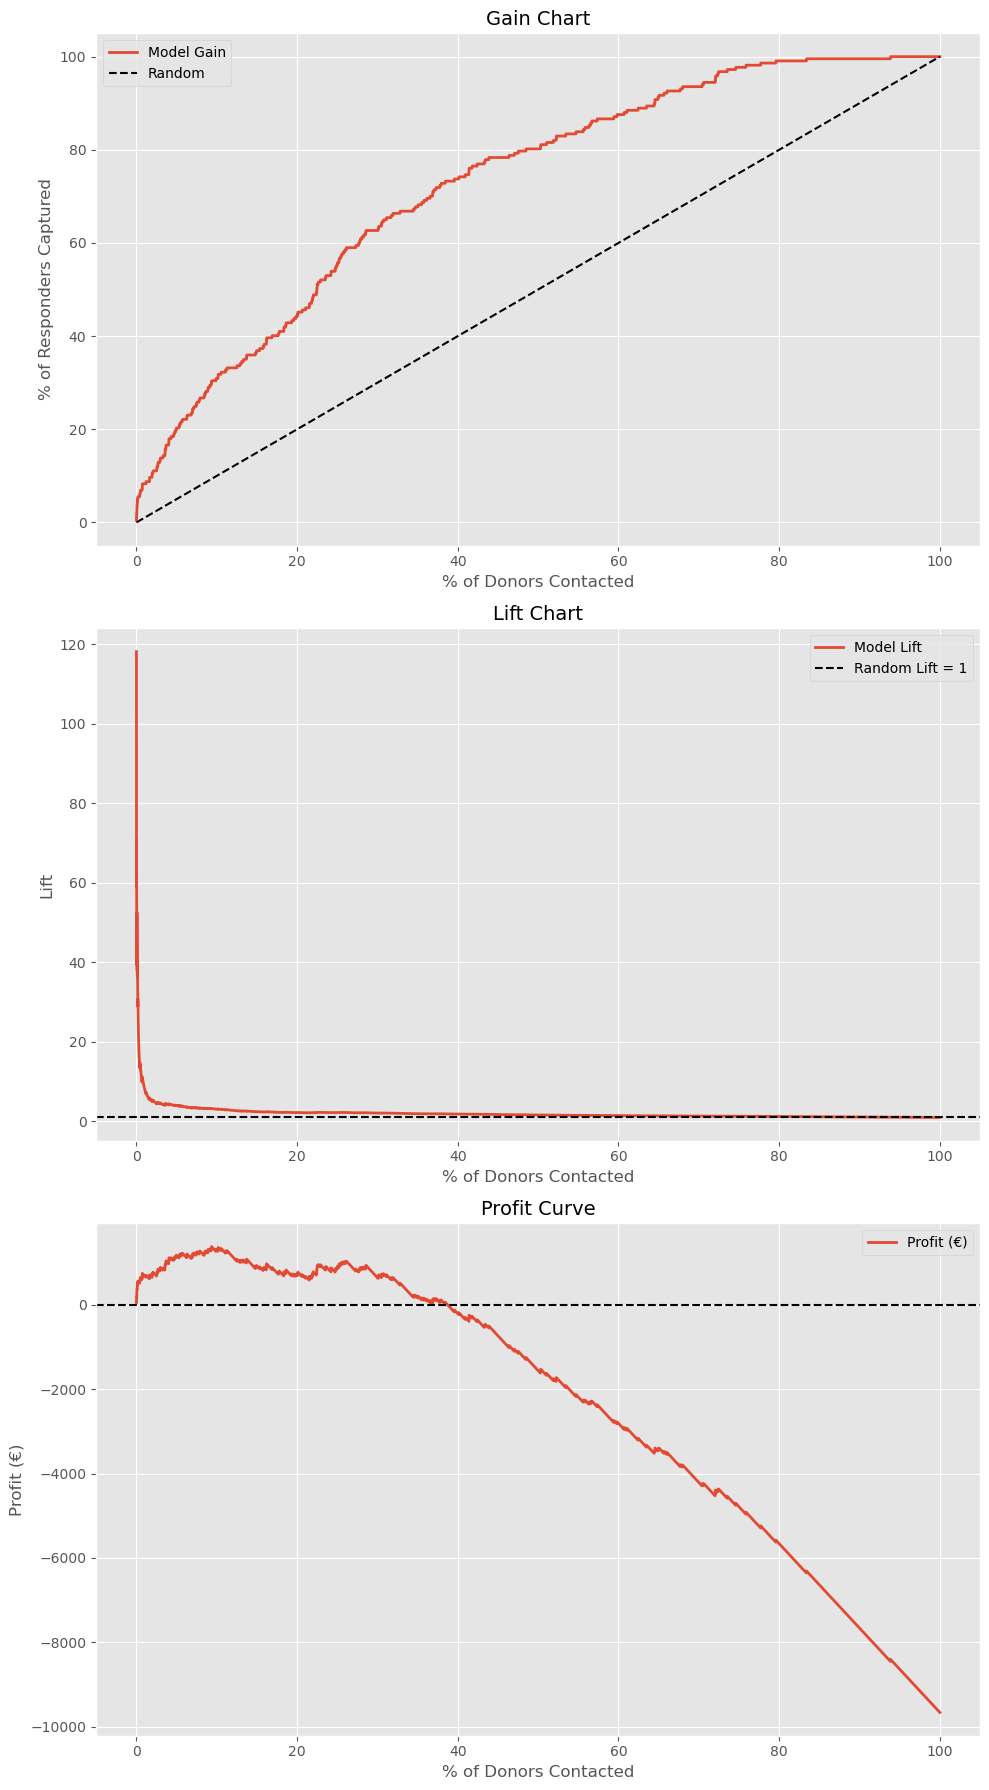

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PREPARE DATA
# -----------------------------
df = pd.DataFrame({
    "y_true": y_test,
    "proba": y_test_proba
}).sort_values("proba", ascending=False).reset_index(drop=True)

df["cum_responders"] = df["y_true"].cumsum()
total_resp = df["y_true"].sum()

df["percent_population"] = (df.index + 1) / len(df) * 100
df["gain"] = df["cum_responders"] / total_resp * 100
df["lift"] = df["gain"] / df["percent_population"]

# Profit curve assumptions
mail_cost = 0.80
avg_donation = 50

df["cost"] = (df.index + 1) * mail_cost
df["revenue"] = df["cum_responders"] * avg_donation
df["profit"] = df["revenue"] - df["cost"]

# -----------------------------
# PLOTS
# -----------------------------
fig, ax = plt.subplots(3, 1, figsize=(10, 18))

# GAIN CHART
ax[0].plot(df["percent_population"], df["gain"], label="Model Gain", linewidth=2)
ax[0].plot([0,100], [0,100], "k--", label="Random")
ax[0].set_title("Gain Chart", fontsize=14)
ax[0].set_xlabel("% of Donors Contacted")
ax[0].set_ylabel("% of Responders Captured")
ax[0].legend()
ax[0].grid(True)

# LIFT CHART
ax[1].plot(df["percent_population"], df["lift"], label="Model Lift", linewidth=2)
ax[1].axhline(1, linestyle="--", color="k", label="Random Lift = 1")
ax[1].set_title("Lift Chart", fontsize=14)
ax[1].set_xlabel("% of Donors Contacted")
ax[1].set_ylabel("Lift")
ax[1].legend()
ax[1].grid(True)

# PROFIT CURVE
ax[2].plot(df["percent_population"], df["profit"], label="Profit (€)", linewidth=2)
ax[2].axhline(0, color="k", linestyle="--")
ax[2].set_title("Profit Curve", fontsize=14)
ax[2].set_xlabel("% of Donors Contacted")
ax[2].set_ylabel("Profit (€)")
ax[2].grid(True)
ax[2].legend()

plt.tight_layout()
plt.show()


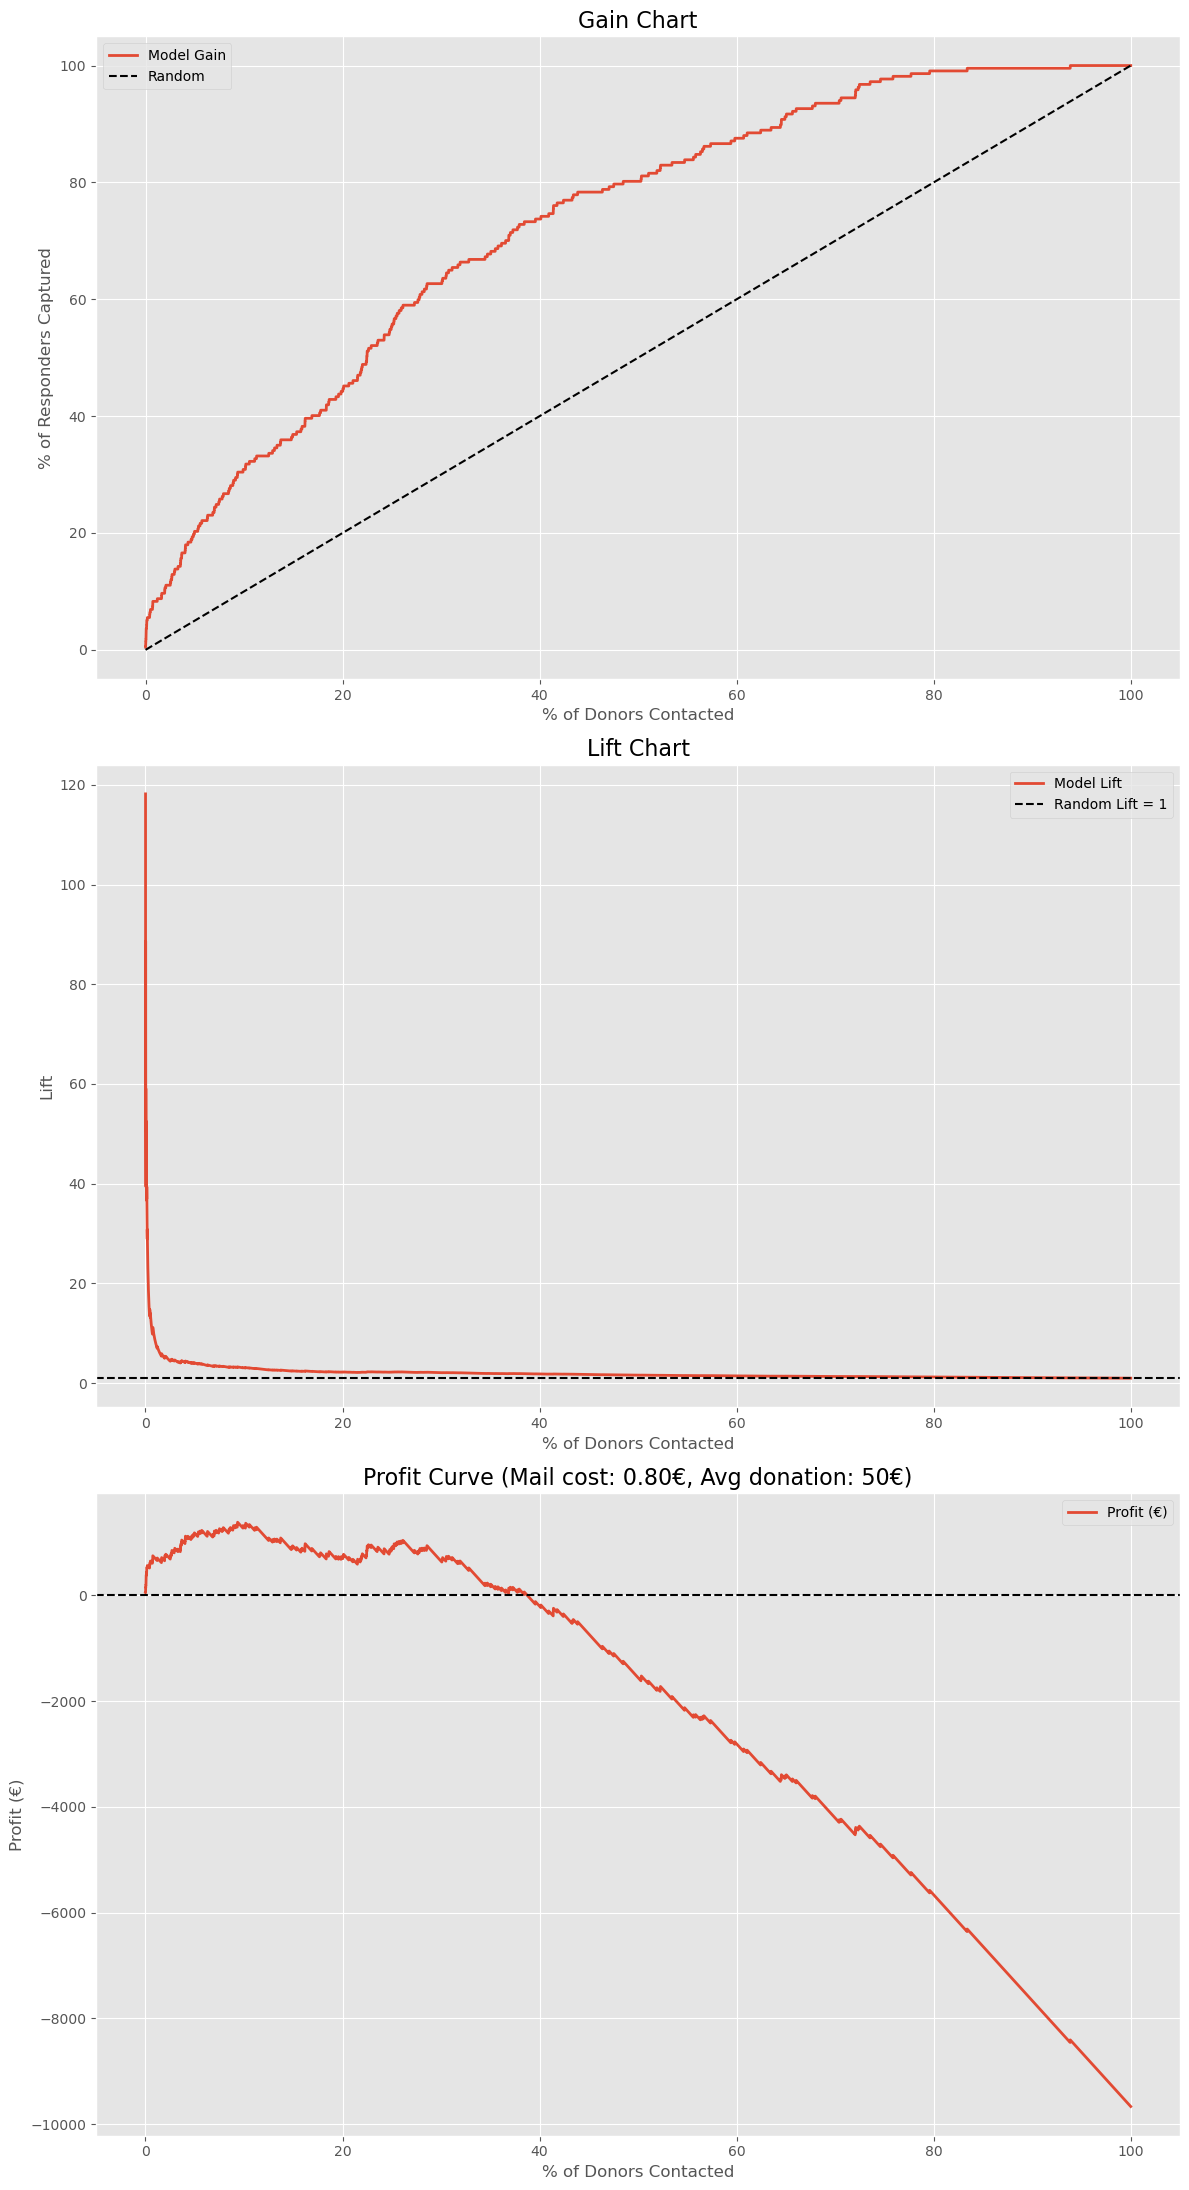

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# PREPARE BASE DATA
# ---------------------------------------------------
df = pd.DataFrame({
    "donorID": test["donorID"],
    "y_true": y_test,
    "proba": y_test_proba
}).sort_values("proba", ascending=False).reset_index(drop=True)

# Gain/Lift calculations
df["cum_responders"] = df["y_true"].cumsum()
total_resp = df["y_true"].sum()
df["percent_population"] = (df.index + 1) / len(df) * 100
df["gain"] = df["cum_responders"] / total_resp * 100
df["lift"] = df["gain"] / df["percent_population"]

# Profit curve assumptions
mail_cost = 0.80
avg_donation = 50
df["cost"] = (df.index + 1) * mail_cost
df["revenue"] = df["cum_responders"] * avg_donation
df["profit"] = df["revenue"] - df["cost"]


# ---------------------------------------------------
# DASHBOARD PLOTS
# ---------------------------------------------------
fig, ax = plt.subplots(3, 1, figsize=(12, 22))

# 1️⃣ Gain Chart
ax[0].plot(df["percent_population"], df["gain"], label="Model Gain", linewidth=2)
ax[0].plot([0,100], [0,100], "k--", label="Random")
ax[0].set_title("Gain Chart", fontsize=16)
ax[0].set_xlabel("% of Donors Contacted")
ax[0].set_ylabel("% of Responders Captured")
ax[0].legend()
ax[0].grid(True)

# 2️⃣ Lift Chart
ax[1].plot(df["percent_population"], df["lift"], label="Model Lift", linewidth=2)
ax[1].axhline(1, linestyle="--", color="k", label="Random Lift = 1")
ax[1].set_title("Lift Chart", fontsize=16)
ax[1].set_xlabel("% of Donors Contacted")
ax[1].set_ylabel("Lift")
ax[1].legend()
ax[1].grid(True)

# 3️⃣ Profit Curve
ax[2].plot(df["percent_population"], df["profit"], label="Profit (€)", linewidth=2)
ax[2].axhline(0, color="k", linestyle="--")
ax[2].set_title("Profit Curve (Mail cost: 0.80€, Avg donation: 50€)", fontsize=16)
ax[2].set_xlabel("% of Donors Contacted")
ax[2].set_ylabel("Profit (€)")
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()





In [90]:
base_rate = y_test.mean()   # overall response rate in test set
N = len(y_test)
total_responders = y_test.sum()

print("Base response rate:", base_rate, "Total responders:", total_responders, "Total donors:", N)


Base response rate: 0.008461688438292064 Total responders: 217 Total donors: 25645


In [91]:
import pandas as pd
import numpy as np

mail_cost = 0.80
avg_donation = 50

segments = {
    "Top 5% (Random)": 0.05,
    "Top 10% (Random)": 0.10,
    "Top 20% (Random)": 0.20,
    "Top 30% (Random)": 0.30,
    "Top 50% (Random)": 0.50
}

random_results = []

for name, frac in segments.items():
    mailed = int(N * frac)
    
    # Expected responders under random selection
    expected_responders = mailed * base_rate
    
    revenue = expected_responders * avg_donation
    cost = mailed * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost > 0 else np.nan

    random_results.append([name, mailed, expected_responders, revenue, cost, profit, roi])

random_baseline = pd.DataFrame(
    random_results,
    columns=["Segment", "Donors Mailed", "Expected Responders", "Revenue (€)", "Cost (€)", "Profit (€)", "ROI"]
)

random_baseline


,Segment,Donors Mailed,Expected Responders,Revenue (€),Cost (€),Profit (€),ROI
0,Top 5% (Random),1282,10.847885,542.394229,1025.6,-483.205771,0.528856
1,Top 10% (Random),2564,21.695769,1084.788458,2051.2,-966.411542,0.528856
2,Top 20% (Random),5129,43.400000,2170.000000,4103.2,-1933.200000,0.528856
3,Top 30% (Random),7693,65.095769,3254.788458,6154.4,-2899.611542,0.528856
4,Top 50% (Random),12822,108.495769,5424.788458,10257.6,-4832.811542,0.528856


In [92]:
random_baseline["Segment"] = random_baseline["Segment"].str.replace(" (Random)", "", regex=False)


In [93]:
combined = profit_table.merge(
    random_baseline,
    on="Segment",
    suffixes=("_Model", "_Random")
)

display(combined)


,Segment,Donors Mailed_Model,Responders,Revenue (€)_Model,Cost (€)_Model,Profit (€)_Model,ROI_Model,Donors Mailed_Random,Expected Responders,Revenue (€)_Random,Cost (€)_Random,Profit (€)_Random,ROI_Random
0,Top 5%,1282,44,2200,1025.6,1174.4,2.145086,1282,10.847885,542.394229,1025.6,-483.205771,0.528856
1,Top 10%,2564,67,3350,2051.2,1298.8,1.633190,2564,21.695769,1084.788458,2051.2,-966.411542,0.528856
2,Top 20%,5129,96,4800,4103.2,696.8,1.169819,5129,43.400000,2170.000000,4103.2,-1933.200000,0.528856
3,Top 30%,7693,136,6800,6154.4,645.6,1.104901,7693,65.095769,3254.788458,6154.4,-2899.611542,0.528856
4,Top 50%,12822,174,8700,10257.6,-1557.6,0.848152,12822,108.495769,5424.788458,10257.6,-4832.811542,0.528856


In [94]:
#botton population

In [95]:
df = pd.DataFrame({
    "y_true": y_test,
    "proba": y_proba
}).sort_values("proba", ascending=False).reset_index(drop=True)

N = len(df)
base_rate = y_test.mean()
mail_cost = 0.80
avg_donation = 50


In [96]:
bottom_segments = {
    "Bottom 10%": 0.10,
    "Bottom 20%": 0.20,
    "Bottom 30%": 0.30,
    "Bottom 50%": 0.50
}


In [97]:
bottom_results = []

for name, frac in bottom_segments.items():
    count = int(N * frac)
    
    # take last X% of donors
    df_bottom = df.tail(count)
    
    mailed = count
    responders = df_bottom["y_true"].sum()
    
    revenue = responders * avg_donation
    cost = mailed * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost > 0 else 0
    
    bottom_results.append([
        name, mailed, responders, revenue, cost, profit, roi
    ])

bottom_table = pd.DataFrame(
    bottom_results,
    columns=[
        "Segment",
        "Donors Mailed",
        "Responders",
        "Revenue (€)",
        "Cost (€)",
        "Profit (€)",
        "ROI"
    ]
)

bottom_table


,Segment,Donors Mailed,Responders,Revenue (€),Cost (€),Profit (€),ROI
0,Bottom 10%,2564,1,50,2051.2,-2001.2,0.024376
1,Bottom 20%,5129,2,100,4103.2,-4003.2,0.024371
2,Bottom 30%,7693,14,700,6154.4,-5454.4,0.113740
3,Bottom 50%,12822,43,2150,10257.6,-8107.6,0.209601


In [98]:
import pandas as pd
import numpy as np

# ===========================
# Setup
# ===========================
mail_cost = 0.80
avg_donation = 50
N = len(df)
base_rate = df["y_true"].mean()

# Segments
top_segments = {
    "Top 5%": 0.05,
    "Top 10%": 0.10,
    "Top 20%": 0.20,
    "Top 30%": 0.30,
    "Top 50%": 0.50
}

bottom_segments = {
    "Bottom 10%": 0.10,
    "Bottom 20%": 0.20,
    "Bottom 30%": 0.30,
    "Bottom 50%": 0.50
}

records = []

# ===========================
# Function to compute performance
# ===========================
def compute_metrics(name, mailed, responders):
    revenue = responders * avg_donation
    cost = mailed * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost > 0 else 0
    
    expected_resp = mailed * base_rate
    rand_revenue = expected_resp * avg_donation
    rand_cost = mailed * mail_cost
    rand_profit = rand_revenue - rand_cost
    rand_roi = rand_revenue / rand_cost if rand_cost > 0 else 0
    
    lift_profit = profit - rand_profit
    lift_roi = roi - rand_roi
    
    return [
        name, mailed, responders, revenue, cost, profit, roi,
        expected_resp, rand_revenue, rand_cost, rand_profit, rand_roi,
        lift_profit, lift_roi
    ]

# ===========================
# Top Segments
# ===========================
for name, frac in top_segments.items():
    count = int(N * frac)
    df_seg = df.head(count)
    responders = df_seg["y_true"].sum()
    records.append(compute_metrics(name, count, responders))


# ===========================
# Bottom Segments
# ===========================
for name, frac in bottom_segments.items():
    count = int(N * frac)
    df_seg = df.tail(count)
    responders = df_seg["y_true"].sum()
    records.append(compute_metrics(name, count, responders))

# ===========================
# Final Table
# ===========================
master_table = pd.DataFrame(
    records,
    columns=[
        "Segment", "Donors_Mailed", "Responders_Model", "Revenue_Model",
        "Cost_Model", "Profit_Model", "ROI_Model",
        "Expected_Responders_Random", "Revenue_Random", "Cost_Random",
        "Profit_Random", "ROI_Random",
        "Profit_Lift", "ROI_Lift"
    ]
)

master_table


,Segment,Donors_Mailed,Responders_Model,Revenue_Model,Cost_Model,Profit_Model,ROI_Model,Expected_Responders_Random,Revenue_Random,Cost_Random,Profit_Random,ROI_Random,Profit_Lift,ROI_Lift
0,Top 5%,1282,44,2200,1025.6,1174.4,2.145086,10.847885,542.394229,1025.6,-483.205771,0.528856,1657.605771,1.616230
1,Top 10%,2564,67,3350,2051.2,1298.8,1.633190,21.695769,1084.788458,2051.2,-966.411542,0.528856,2265.211542,1.104335
2,Top 20%,5129,96,4800,4103.2,696.8,1.169819,43.400000,2170.000000,4103.2,-1933.200000,0.528856,2630.000000,0.640963
3,Top 30%,7693,136,6800,6154.4,645.6,1.104901,65.095769,3254.788458,6154.4,-2899.611542,0.528856,3545.211542,0.576045
4,Top 50%,12822,174,8700,10257.6,-1557.6,0.848152,108.495769,5424.788458,10257.6,-4832.811542,0.528856,3275.211542,0.319296
5,Bottom 10%,2564,1,50,2051.2,-2001.2,0.024376,21.695769,1084.788458,2051.2,-966.411542,0.528856,-1034.788458,-0.504480
6,Bottom 20%,5129,2,100,4103.2,-4003.2,0.024371,43.400000,2170.000000,4103.2,-1933.200000,0.528856,-2070.000000,-0.504484
7,Bottom 30%,7693,14,700,6154.4,-5454.4,0.113740,65.095769,3254.788458,6154.4,-2899.611542,0.528856,-2554.788458,-0.415116
8,Bottom 50%,12822,43,2150,10257.6,-8107.6,0.209601,108.495769,5424.788458,10257.6,-4832.811542,0.528856,-3274.788458,-0.319255


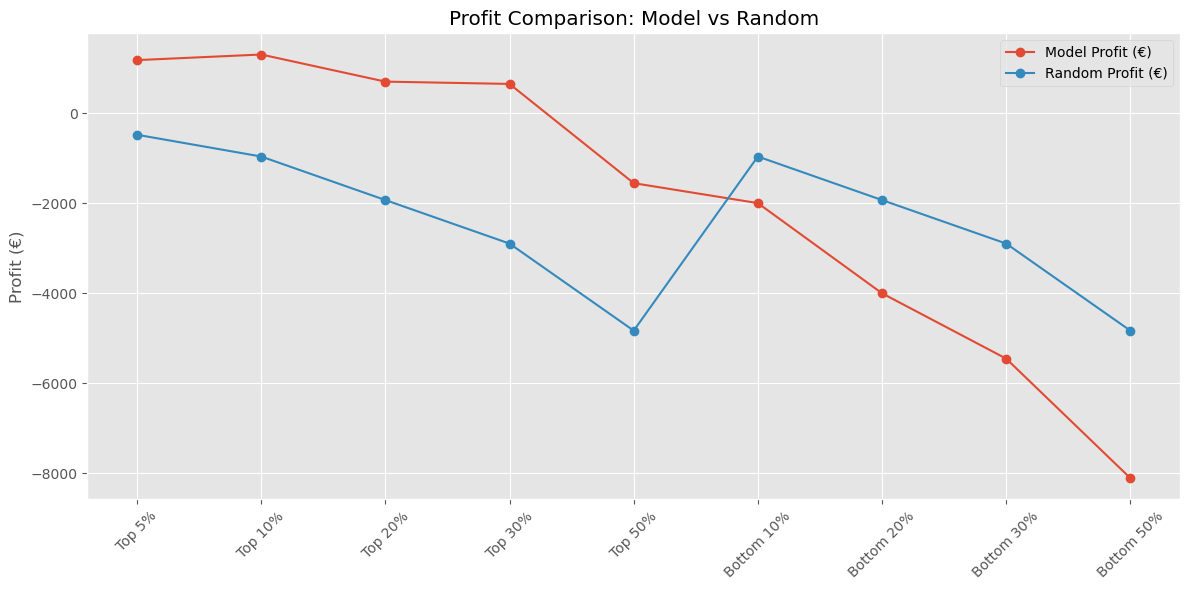

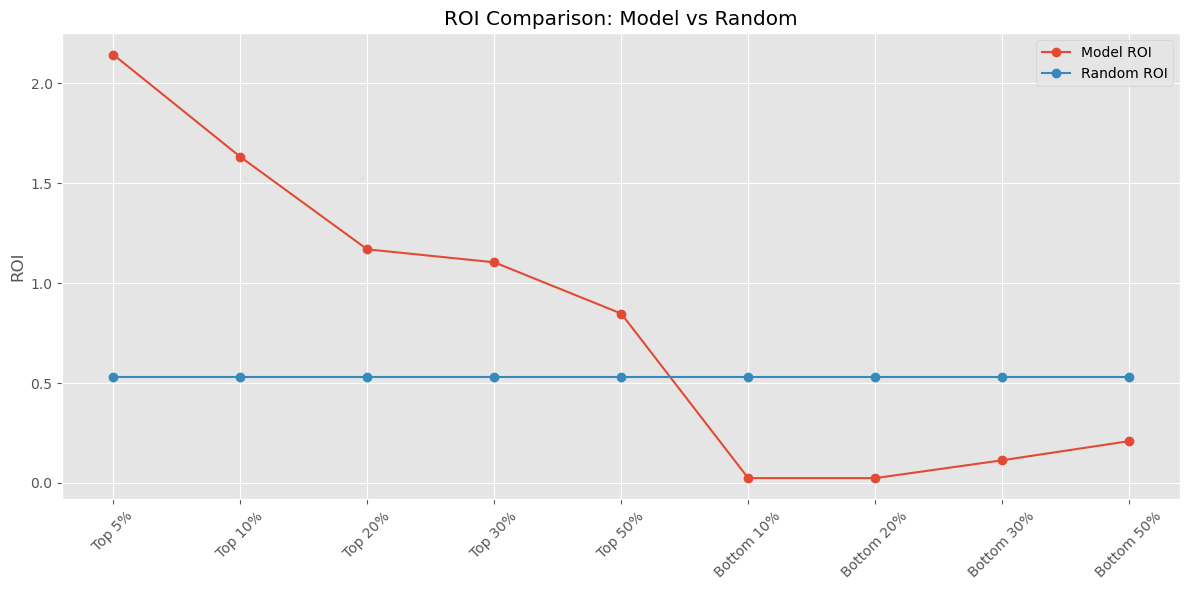

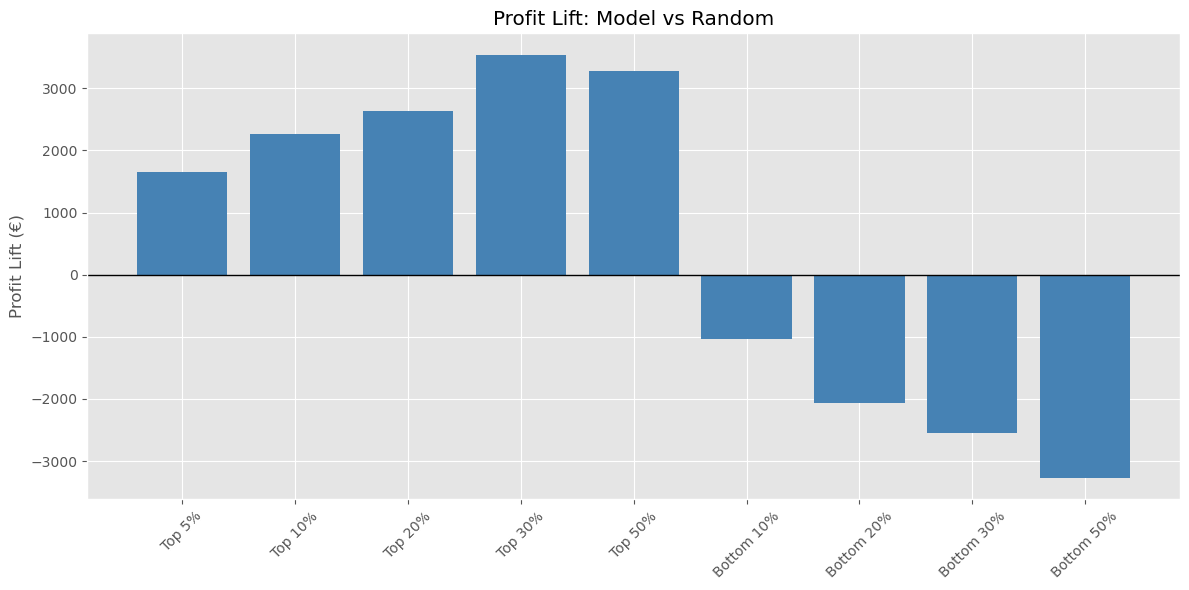

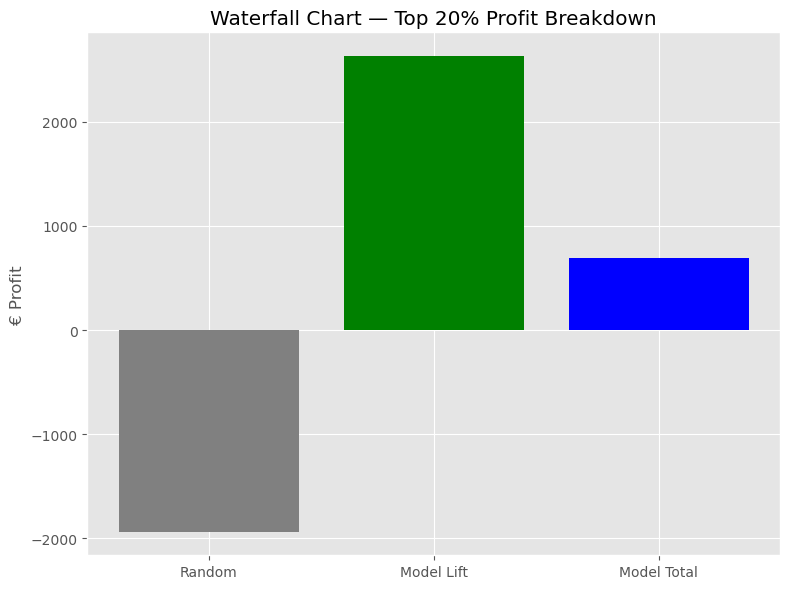

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure segments appear sorted in correct business order
order = [
    "Top 5%", "Top 10%", "Top 20%", "Top 30%", "Top 50%",
    "Bottom 10%", "Bottom 20%", "Bottom 30%", "Bottom 50%"
]

master_table_sorted = master_table.set_index("Segment").loc[order].reset_index()

plt.style.use("ggplot")

# ===============================
# 1. Profit Chart — Model vs Random
# ===============================
plt.figure(figsize=(12,6))
plt.plot(master_table_sorted["Segment"], master_table_sorted["Profit_Model"], marker='o', label="Model Profit (€)")
plt.plot(master_table_sorted["Segment"], master_table_sorted["Profit_Random"], marker='o', label="Random Profit (€)")
plt.xticks(rotation=45)
plt.ylabel("Profit (€)")
plt.title("Profit Comparison: Model vs Random")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# 2. ROI Chart — Model vs Random
# ===============================
plt.figure(figsize=(12,6))
plt.plot(master_table_sorted["Segment"], master_table_sorted["ROI_Model"], marker='o', label="Model ROI")
plt.plot(master_table_sorted["Segment"], master_table_sorted["ROI_Random"], marker='o', label="Random ROI")
plt.xticks(rotation=45)
plt.ylabel("ROI")
plt.title("ROI Comparison: Model vs Random")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# 3. Profit Lift Chart
# ===============================
plt.figure(figsize=(12,6))
plt.bar(master_table_sorted["Segment"], master_table_sorted["Profit_Lift"], color='steelblue')
plt.xticks(rotation=45)
plt.ylabel("Profit Lift (€)")
plt.title("Profit Lift: Model vs Random")
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

# ===============================
# 4. Waterfall Chart for Top 20% Only (optional)
# ===============================
top20 = master_table_sorted[master_table_sorted["Segment"] == "Top 20%"].iloc[0]

profit_random = top20["Profit_Random"]
profit_model = top20["Profit_Model"]
profit_gain = top20["Profit_Lift"]

plt.figure(figsize=(8,6))
bars = [profit_random, profit_gain, profit_model]

plt.bar(["Random", "Model Lift", "Model Total"], bars, color=["gray", "green", "blue"])
plt.title("Waterfall Chart — Top 20% Profit Breakdown")
plt.ylabel("€ Profit")
plt.grid(True)
plt.tight_layout()
plt.show()


In [100]:
#real amount

In [101]:
import pandas as pd

# Filter gifts for TEST campaign + date window (same as model target)
test_drop_date = pd.to_datetime("18/06/2019", format="%d/%m/%Y")
test_end_date = test_drop_date + pd.Timedelta(days=250)

gifts_test_window = gifts[
    (gifts["campaignID"] == 7244) &
    (gifts["date"] > test_drop_date) &
    (gifts["date"] <= test_end_date)
]

# Actual donation per donor
actual_revenue = (
    gifts_test_window.groupby("donorID")["amount_cleaned"]
    .sum()
    .rename("actual_revenue")
)


In [102]:
df = pd.DataFrame({
    "donorID": test["donorID"],
    "y_true": y_test,
    "proba": y_proba
}).sort_values("proba", ascending=False).reset_index(drop=True)


In [103]:
df = df.merge(actual_revenue, on="donorID", how="left")

df["actual_revenue"] = df["actual_revenue"].fillna(0)


In [104]:
mail_cost = 0.80
N = len(df)

segments = {
    "Top 5%": 0.05,
    "Top 10%": 0.10,
    "Top 20%": 0.20,
    "Top 30%": 0.30,
    "Top 50%": 0.50
}

real_results = []

for name, frac in segments.items():
    count = int(N * frac)
    df_seg = df.head(count)

    donors = count
    revenue = df_seg["actual_revenue"].sum()
    cost = donors * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost else 0

    # responder counts
    responders_30 = (df_seg["actual_revenue"] >= 30).sum()
    responders_any = (df_seg["actual_revenue"] > 0).sum()

    real_results.append([
        name,
        donors,
        responders_30,
        responders_any,
        revenue,
        cost,
        profit,
        roi
    ])

real_profit_table = pd.DataFrame(
    real_results,
    columns=[
        "Segment",
        "Donors_Mailed",
        "Responders_≥30",
        "Responders_Any",
        "Revenue (€)",
        "Cost (€)",
        "Profit (€)",
        "ROI"
    ]
)

real_profit_table


,Segment,Donors_Mailed,Responders_≥30,Responders_Any,Revenue (€),Cost (€),Profit (€),ROI
0,Top 5%,1282,44,59,3762.0,1025.6,2736.4,3.668097
1,Top 10%,2564,67,87,5432.0,2051.2,3380.8,2.648206
2,Top 20%,5129,96,133,8048.0,4103.2,3944.8,1.961396
3,Top 30%,7693,136,187,11416.0,6154.4,5261.6,1.854933
4,Top 50%,12822,174,237,14282.0,10257.6,4024.4,1.392333


In [105]:
mail_cost = 0.80
N = len(df)

top_segments = {
    "Top 5%": 0.05,
    "Top 10%": 0.10,
    "Top 20%": 0.20,
    "Top 30%": 0.30,
    "Top 50%": 0.50
}

bottom_segments = {
    "Bottom 10%": 0.10,
    "Bottom 20%": 0.20,
    "Bottom 30%": 0.30,
    "Bottom 50%": 0.50
}

results = []

# ==========================
# FUNCTION TO COMPUTE METRICS
# ==========================
def compute_metrics(name, df_seg):
    donors = len(df_seg)
    revenue = df_seg["actual_revenue"].sum()
    cost = donors * mail_cost
    profit = revenue - cost
    roi = revenue / cost if cost else 0
    
    responders_30 = (df_seg["actual_revenue"] >= 30).sum()
    responders_any = (df_seg["actual_revenue"] > 0).sum()
    
    return [
        name,
        donors,
        responders_30,
        responders_any,
        revenue,
        cost,
        profit,
        roi
    ]

# ==========================
# TOP SEGMENTS
# ==========================
for name, frac in top_segments.items():
    count = int(N * frac)
    df_seg = df.head(count)
    results.append(compute_metrics(name, df_seg))

# ==========================
# BOTTOM SEGMENTS
# ==========================
for name, frac in bottom_segments.items():
    count = int(N * frac)
    df_seg = df.tail(count)
    results.append(compute_metrics(name, df_seg))

# ==========================
# FINAL TABLE
# ==========================
real_profit_table_full = pd.DataFrame(
    results,
    columns=[
        "Segment",
        "Donors_Mailed",
        "Responders_≥30",
        "Responders_Any",
        "Revenue (€)",
        "Cost (€)",
        "Profit (€)",
        "ROI"
    ]
)

real_profit_table_full


,Segment,Donors_Mailed,Responders_≥30,Responders_Any,Revenue (€),Cost (€),Profit (€),ROI
0,Top 5%,1282,44,59,3762.0,1025.6,2736.4,3.668097
1,Top 10%,2564,67,87,5432.0,2051.2,3380.8,2.648206
2,Top 20%,5129,96,133,8048.0,4103.2,3944.8,1.961396
3,Top 30%,7693,136,187,11416.0,6154.4,5261.6,1.854933
4,Top 50%,12822,174,237,14282.0,10257.6,4024.4,1.392333
5,Bottom 10%,2564,1,25,224.0,2051.2,-1827.2,0.109204
6,Bottom 20%,5129,2,41,468.0,4103.2,-3635.2,0.114057
7,Bottom 30%,7693,14,61,1775.0,6154.4,-4379.4,0.288412
8,Bottom 50%,12822,43,124,4334.0,10257.6,-5923.6,0.422516


In [106]:
#feature importance

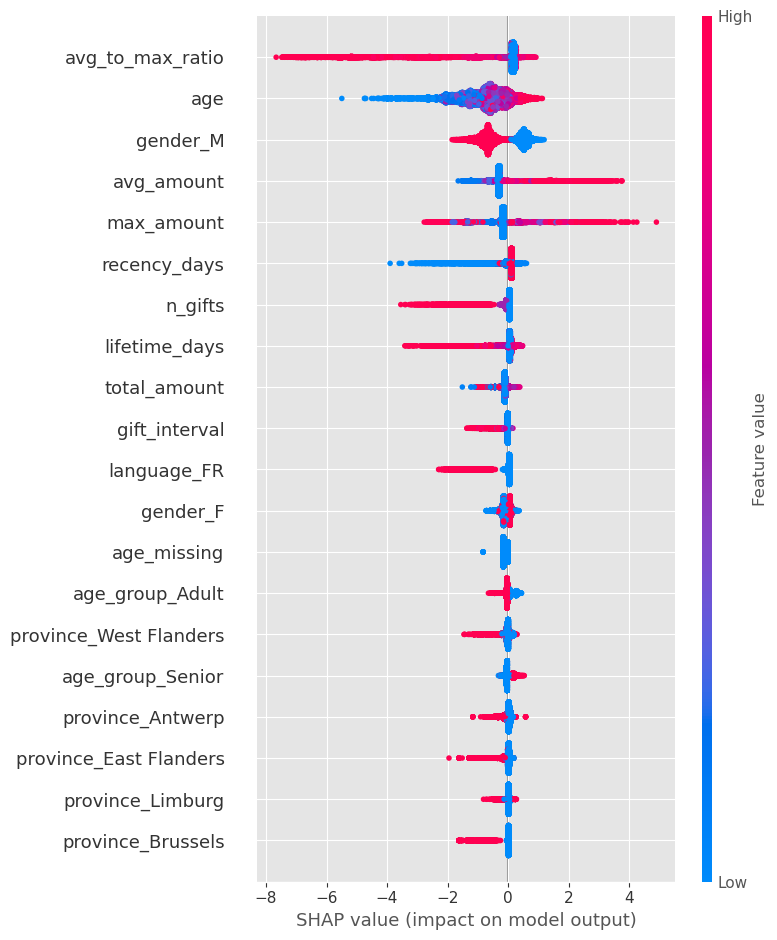

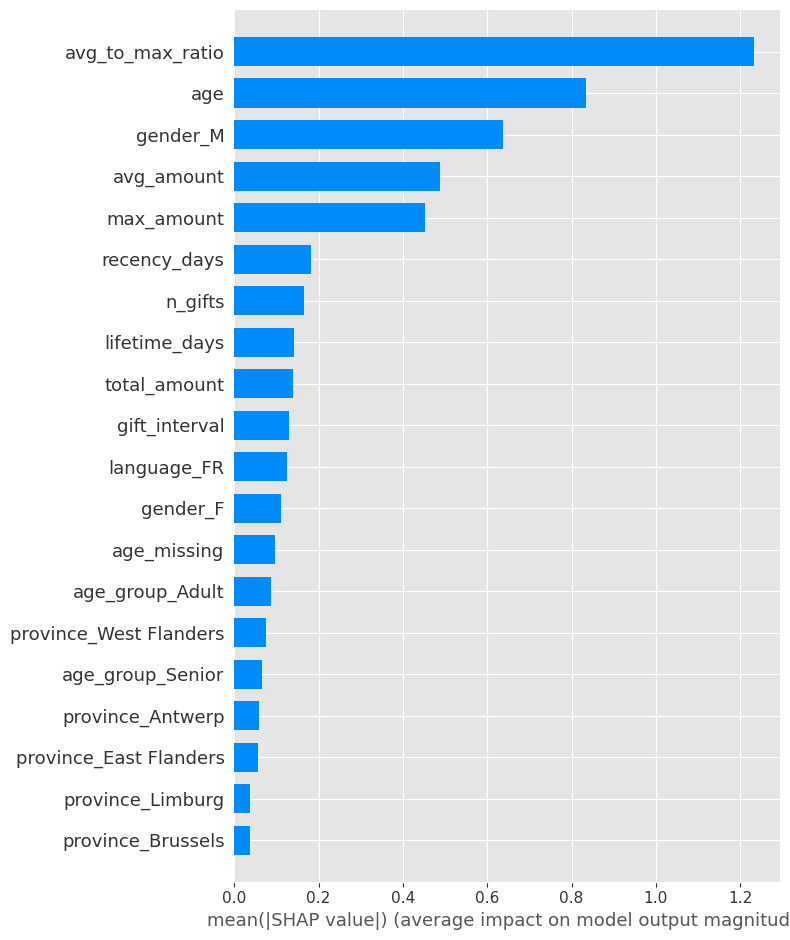

In [107]:
# ============================
# SHAP EXPLAINABILITY FOR XGBOOST
# ============================
import shap
import numpy as np

# Ensure JS visualization works (optional)
shap.initjs()

# Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test_scaled)

# If output is list (older XGBoost versions), unwrap it
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Feature names
feature_names = X_train.columns

# ============================
# 1️⃣ SHAP SUMMARY PLOT
# ============================
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=True
)

# ============================
# 2️⃣ SHAP FEATURE IMPORTANCE BAR PLOT
# ============================
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# ============================
# 3️⃣ OPTIONAL — EXPLAIN ONE DONOR
# ============================
donor_index = 0  # change this to inspect another donor

shap.force_plot(
    explainer.expected_value,
    shap_values[donor_index],
    X_test_scaled[donor_index,:],
    feature_names=feature_names
)


Saved: shap_summary.jpg
Saved: shap_barplot.jpg


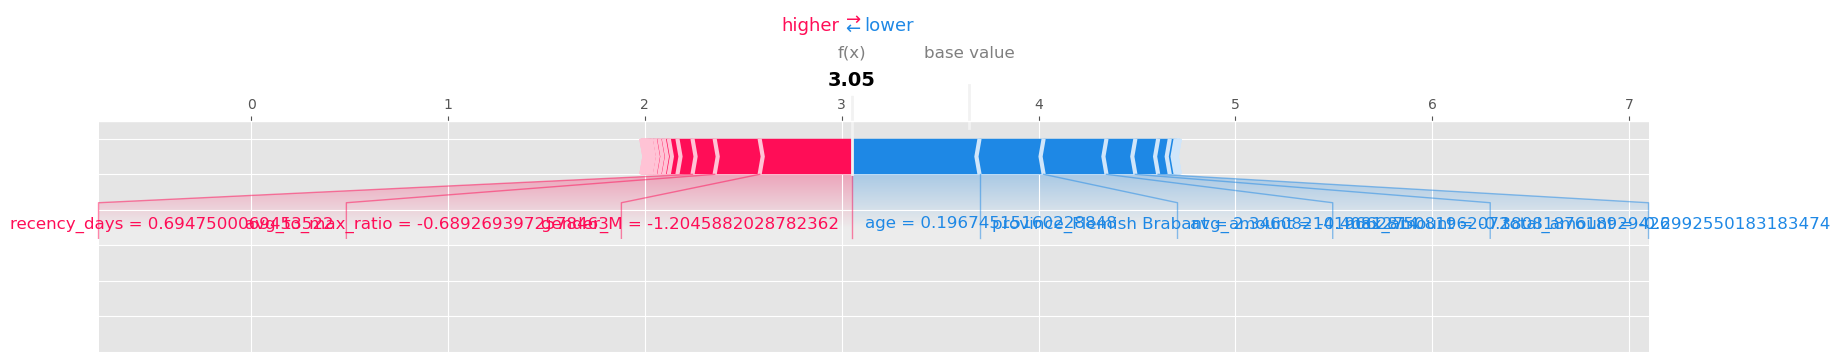

Saved: shap_forceplot_donor0.jpg


In [108]:
# ===========================================
# SHAP EXPLAINABILITY + SAVE PLOTS TO JPG
# ===========================================
import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize SHAP
shap.initjs()

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test_scaled)

# Fix: unwrap if SHAP returns list
if isinstance(shap_values, list):
    shap_values = shap_values[0]

feature_names = X_train.columns


# =====================================================
# 1️⃣ SHAP SUMMARY PLOT  (Beeswarm)
# =====================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary.jpg", dpi=300, bbox_inches='tight')
plt.close()

print("Saved: shap_summary.jpg")


# =====================================================
# 2️⃣ SHAP FEATURE IMPORTANCE BAR PLOT
# =====================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("shap_barplot.jpg", dpi=300, bbox_inches='tight')
plt.close()

print("Saved: shap_barplot.jpg")


# =====================================================
# 3️⃣ OPTIONAL — SHAP FORCE PLOT FOR ONE DONOR (saved)
# =====================================================
donor_index = 0

force = shap.force_plot(
    explainer.expected_value,
    shap_values[donor_index],
    X_test_scaled[donor_index,:],
    feature_names=feature_names,
    matplotlib=True
)

plt.savefig("shap_forceplot_donor0.jpg", dpi=300, bbox_inches='tight')
plt.close()

print("Saved: shap_forceplot_donor0.jpg")


In [124]:
# ===============================================
# 1. LOAD NEW DONOR LIST (ensure column is donorID)
# ===============================================
new_list = pd.read_csv(".\selection campaign 7362.csv")

# ===============================================
# 2. BUILD FEATURES
# ===============================================
new_features =build_features(donors, gifts, new_list,campaignID=7362,
                       drop_date="01/02/2020",median_age=train_median_age)
    


# ===============================================
# 3. ALIGN WITH TRAIN DATA
new_features_aligned, _ = new_features.align(train, join="left", axis=1, fill_value=0)

# Drop non-feature columns
X_new = new_features_aligned.drop(columns=["donorID", "target"], errors="ignore")

#  FIX: enforce same column order as training
X_new = X_new[X_train.columns]

# 4. SCALE
X_new_scaled = scaler.transform(X_new)

# 5. PREDICT
new_proba = xgb_model.predict_proba(X_new_scaled)[:, 1]
new_features_aligned["predicted_proba"] = new_proba

# ===============================================
# 6. DECILES
# ===============================================
new_features_aligned["decile"] = pd.qcut(
    new_features_aligned["predicted_proba"],
    10,
    labels=False,
    duplicates="drop"
)

# ===============================================
# 7. CONTACT FLAG (Top 20%)
# ===============================================
new_features_aligned["contact_flag"] = np.where(
    new_features_aligned["decile"] >= 8,
    "MAIL",
    "DO_NOT_MAIL"
)

# ===============================================
# 8. SAVE
# ===============================================
output = new_features_aligned[["donorID", "predicted_proba","contact_flag"]]
output.to_csv("donor_contact_recommendations.csv", index=False)

print("DONE! Saved: donor_contact_recommendations.csv")
print(output.head())


DONE! Saved: donor_contact_recommendations.csv
   donorID  predicted_proba contact_flag
0  D134242         0.854516  DO_NOT_MAIL
1  D126503         0.003540  DO_NOT_MAIL
2  D104392         0.009710  DO_NOT_MAIL
3  D105905         0.178602  DO_NOT_MAIL
4  D120506         0.903790  DO_NOT_MAIL


In [126]:
output[output['contact_flag']== 'MAIL'].head(20)

,donorID,predicted_proba,contact_flag
6,D126159,0.970372,MAIL
9,D133551,0.983079,MAIL
16,D121937,0.993295,MAIL
18,D113805,0.985947,MAIL
19,D112360,0.961850,MAIL
30,D109613,0.985408,MAIL
31,D125090,0.972035,MAIL
33,D102042,0.977902,MAIL
34,D136934,0.978810,MAIL
35,D126262,0.978159,MAIL


In [127]:
# Select top 20% predicted donors (contact group)
cutoff = np.percentile(y_proba, 80)
contact_group = test[y_proba >= cutoff].copy()
contact_group["predicted_proba"] = y_proba[y_proba >= cutoff]

print("Donors in contact group:", len(contact_group))


Donors in contact group: 5154


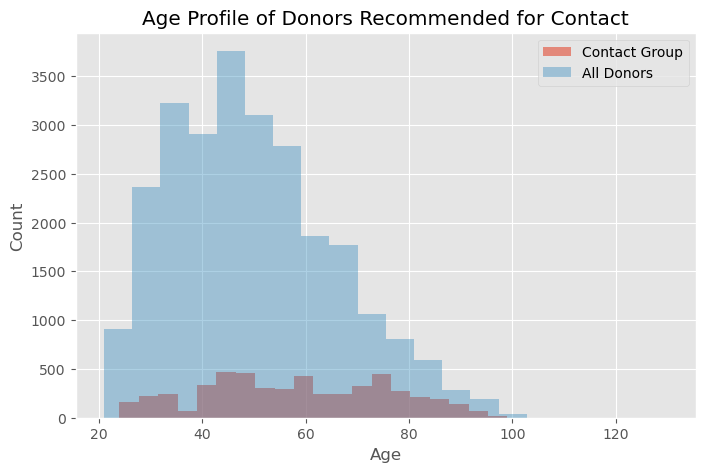

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(contact_group["age"], bins=20, alpha=0.6, label="Contact Group")
plt.hist(test["age"], bins=20, alpha=0.4, label="All Donors")
plt.title("Age Profile of Donors Recommended for Contact")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()


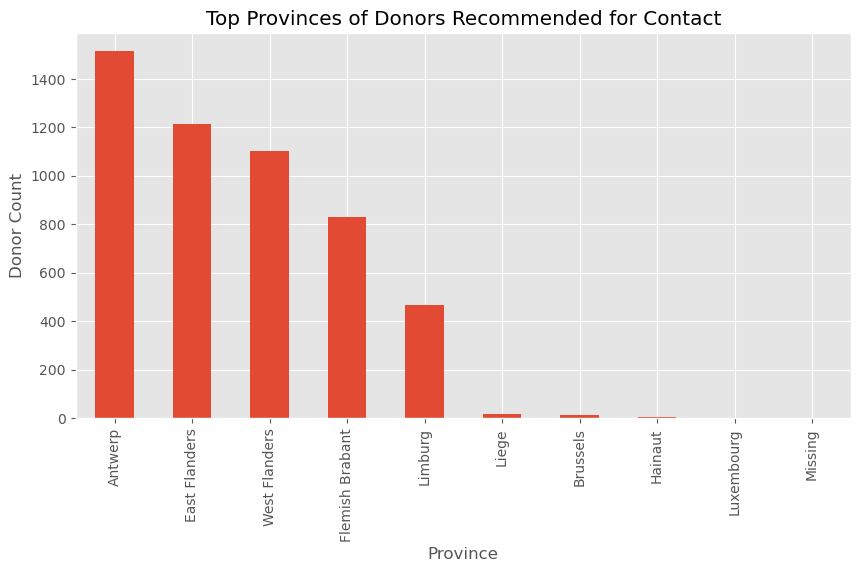

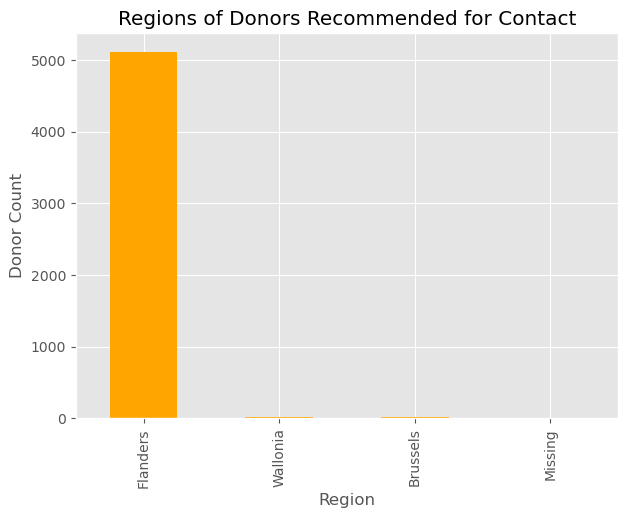

In [136]:
import matplotlib.pyplot as plt

# =====================================================
# 1. Identify dummy columns for province and region
# =====================================================
province_cols = [c for c in contact_group.columns if c.startswith("province_")]
region_cols   = [c for c in contact_group.columns if c.startswith("region_")]

# =====================================================
# 2. Decode province dummy columns
# =====================================================
def decode_province(row):
    for col in province_cols:
        if row[col] == 1:
            return col.replace("province_", "")
    return "Unknown"

contact_group["province_decoded"] = contact_group.apply(decode_province, axis=1)

# =====================================================
# 3. Decode region dummy columns
# =====================================================
def decode_region(row):
    for col in region_cols:
        if row[col] == 1:
            return col.replace("region_", "")
    return "Unknown"

contact_group["region_decoded"] = contact_group.apply(decode_region, axis=1)

# =====================================================
# 4. Plot province distribution
# =====================================================
plt.figure(figsize=(10,5))
contact_group["province_decoded"].value_counts().head(10).plot(kind="bar")
plt.title("Top Provinces of Donors Recommended for Contact")
plt.xlabel("Province")
plt.ylabel("Donor Count")
plt.show()

# =====================================================
# 5. Plot region distribution
# =====================================================
plt.figure(figsize=(7,5))
contact_group["region_decoded"].value_counts().plot(kind="bar", color="orange")
plt.title("Regions of Donors Recommended for Contact")
plt.xlabel("Region")
plt.ylabel("Donor Count")
plt.show()




========== Province Distribution ==========
province
Antwerp            1513
East Flanders      1211
West Flanders      1102
Flemish Brabant     828
Limburg             468
Liege                16
Brussels             11
Hainaut               2
Luxembourg            1
Missing               1
Namur                 1
Name: count, dtype: int64


========== Region Distribution ==========
region
Flanders    5122
Wallonia      20
Brussels      11
Missing        1
Name: count, dtype: int64


========== Gender Distribution ==========
gender
F    4287
M     867
Name: count, dtype: int64


========== Language Distribution ==========
language
NL    5105
FR      47
EN       2
Name: count, dtype: int64


========== Age Group Distribution ==========
age_group
Adult          2523
Senior         2009
Young Adult     622
Name: count, dtype: int64


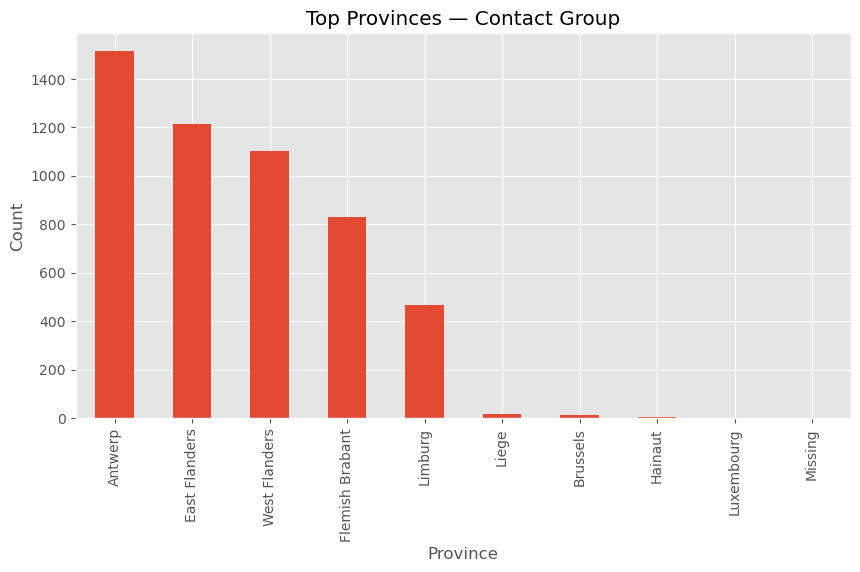

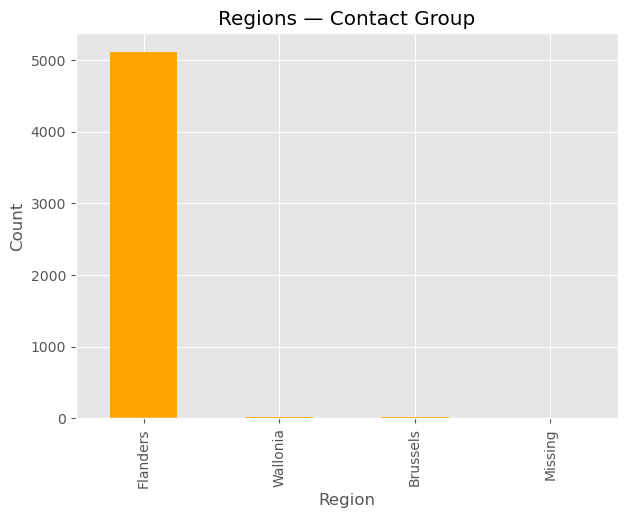

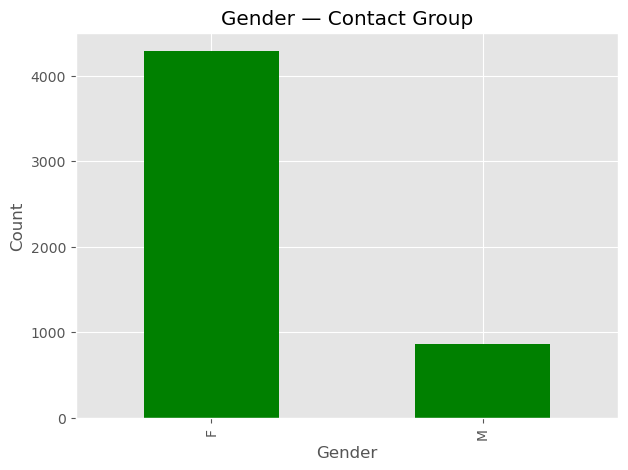

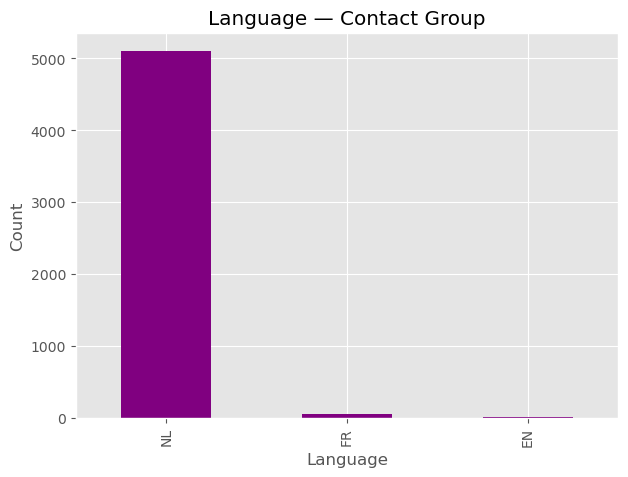

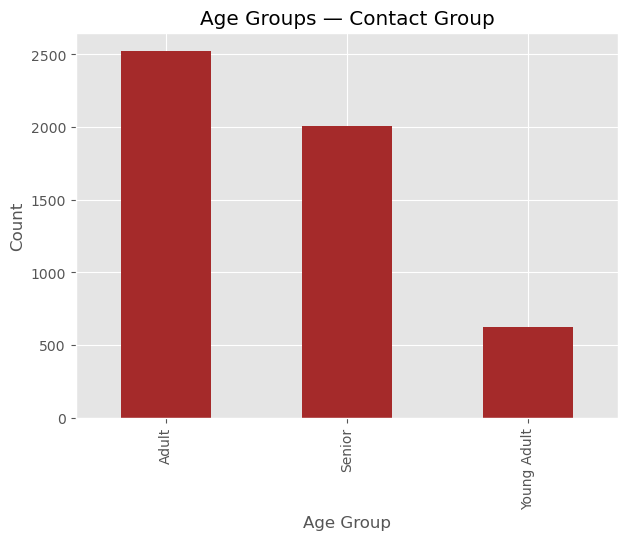

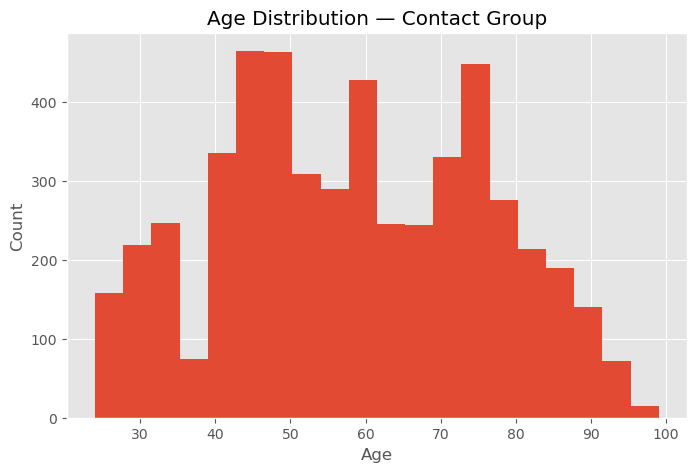

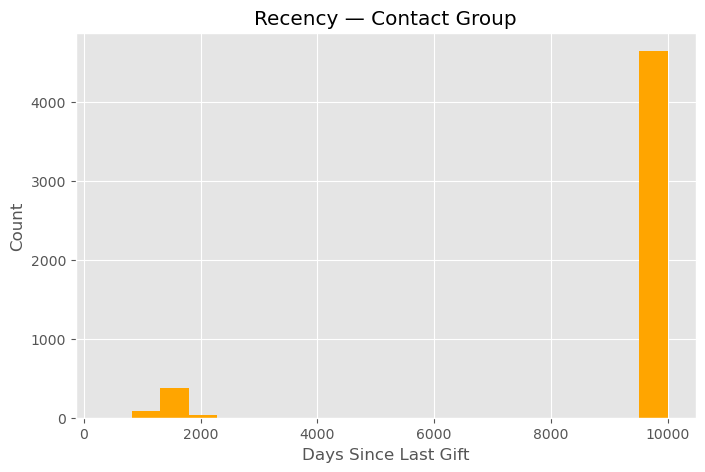

In [139]:
import matplotlib.pyplot as plt

# =====================================================
# 1. IDENTIFY ALL DUMMY COLUMNS
# =====================================================
province_cols = [c for c in contact_group.columns if c.startswith("province_")]
region_cols   = [c for c in contact_group.columns if c.startswith("region_")]
gender_cols   = [c for c in contact_group.columns if c.startswith("gender_")]
language_cols = [c for c in contact_group.columns if c.startswith("language_")]
age_cols      = [c for c in contact_group.columns if c.startswith("age_group_")]

# =====================================================
# 2. DECODER FUNCTION
# =====================================================
def decode_onehot(row, col_list, prefix):
    for col in col_list:
        if row[col] == 1:
            return col.replace(prefix, "")
    return "Unknown"

# =====================================================
# 3. APPLY DECODING
# =====================================================
contact_group["province"]   = contact_group.apply(lambda r: decode_onehot(r, province_cols, "province_"), axis=1)
contact_group["region"]     = contact_group.apply(lambda r: decode_onehot(r, region_cols, "region_"), axis=1)
contact_group["gender"]     = contact_group.apply(lambda r: decode_onehot(r, gender_cols, "gender_"), axis=1)
contact_group["language"]   = contact_group.apply(lambda r: decode_onehot(r, language_cols, "language_"), axis=1)
contact_group["age_group"]  = contact_group.apply(lambda r: decode_onehot(r, age_cols, "age_group_"), axis=1)

# =====================================================
# 4. SUMMARY TABLE
# =====================================================
profile_summary = {
    "Province Distribution": contact_group["province"].value_counts(),
    "Region Distribution":   contact_group["region"].value_counts(),
    "Gender Distribution":   contact_group["gender"].value_counts(),
    "Language Distribution": contact_group["language"].value_counts(),
    "Age Group Distribution":contact_group["age_group"].value_counts(),
}

for title, dist in profile_summary.items():
    print("\n\n==========", title, "==========")
    print(dist)

# =====================================================
# 5. VISUALS — BAR CHARTS FOR CATEGORIES
# =====================================================
plt.figure(figsize=(10,5))
contact_group["province"].value_counts().head(10).plot(kind="bar")
plt.title("Top Provinces — Contact Group")
plt.xlabel("Province")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
contact_group["region"].value_counts().plot(kind="bar", color="orange")
plt.title("Regions — Contact Group")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
contact_group["gender"].value_counts().plot(kind="bar", color="green")
plt.title("Gender — Contact Group")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
contact_group["language"].value_counts().plot(kind="bar", color="purple")
plt.title("Language — Contact Group")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
contact_group["age_group"].value_counts().plot(kind="bar", color="brown")
plt.title("Age Groups — Contact Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# =====================================================
# 6. NUMERICAL HISTOGRAMS
# =====================================================

plt.figure(figsize=(8,5))
contact_group["age"].hist(bins=20)
plt.title("Age Distribution — Contact Group")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
contact_group["recency_days"].hist(bins=20, color="orange")
plt.title("Recency — Contact Group")
plt.xlabel("Days Since Last Gift")
plt.ylabel("Count")
plt.show()





